# **1. Linear Regression**

---

## 📌 What is Linear Regression?

Linear regression is a **supervised learning algorithm** used to model the **relationship between a dependent variable (y)** and one or more **independent variables (x)** by fitting a **linear equation** to observed data.

### For one feature (Simple Linear Regression):

$$
y = mx + b \quad \text{or} \quad y = \theta_0 + \theta_1 x
$$

---

## 🔢 Objective: Minimize the Error

The **goal** is to find the best-fitting line that **minimizes the total error** between the predicted and actual values.

We use the **Least Squares Error**:

$$
\text{Cost Function } J(\theta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Where:

* $y_i$: actual value
* $\hat{y}_i$: predicted value = $\theta_0 + \theta_1 x_i$

This is also called **Mean Squared Error (MSE)**.

---

## 🧠 Least Squares Solution (Closed Form)

We can find optimal values of parameters $\theta$ by solving:

$$
\theta = (X^TX)^{-1}X^Ty
$$

Where:

* $X$: matrix of features (with a bias column of 1’s)
* $y$: vector of outputs

This is known as the **Normal Equation**.

---

## 🧪 Example

Suppose we have:

| x | y |
| - | - |
| 1 | 2 |
| 2 | 3 |
| 3 | 5 |
| 4 | 7 |

We want to fit $y = \theta_0 + \theta_1 x$

1. Build matrix X:

$$
X = \begin{bmatrix}
1 & 1 \\
1 & 2 \\
1 & 3 \\
1 & 4 \\
\end{bmatrix}, \quad
y = \begin{bmatrix}
2 \\
3 \\
5 \\
7 \\
\end{bmatrix}
$$

2. Solve using $\theta = (X^TX)^{-1}X^Ty$

---

## 📉 Visualization

The best-fit line minimizes the vertical distance (errors) from each point to the line:

![Least Squares Line](https://upload.wikimedia.org/wikipedia/commons/3/3a/Linear_regression.svg)

---

## ✅ Summary

| Concept           | Explanation                                    |
| ----------------- | ---------------------------------------------- |
| Linear Regression | Predicts a continuous value                    |
| Least Squares     | Minimizes squared error                        |
| Normal Equation   | $\theta = (X^TX)^{-1}X^Ty$                     |
| Cost Function     | MSE (Mean Squared Error)                       |
| Use Cases         | House prices, stock prediction, trend analysis |

---
---
---

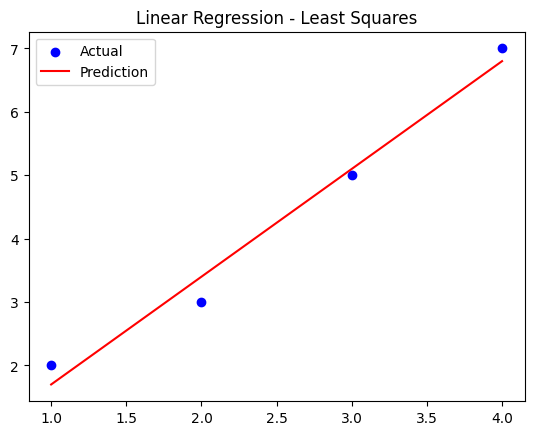

Theta values: [0.  1.7]


In [9]:
## ⚙️ Python Code (Using NumPy)

import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.array([1, 2, 3, 4])
y = np.array([2, 3, 5, 7])

# Add bias (intercept)
X = np.c_[np.ones(x.shape[0]), x]

# Closed-form solution
theta = np.linalg.inv(X.T @ X) @ X.T @ y

# Prediction
y_pred = X @ theta

# Plot
plt.scatter(x, y, color='blue', label='Actual')
plt.plot(x, y_pred, color='red', label='Prediction')
plt.legend()
plt.title("Linear Regression - Least Squares")
plt.show()

print(f"Theta values: {theta}")


# **2. Logistic Regression**

---

## 📌 What is Logistic Regression?

Despite its name, **Logistic Regression is used for classification**, not regression. It predicts the **probability** of a **binary outcome** (yes/no, spam/ham, 0/1).

---

### 🔁 Difference from Linear Regression:

| Linear Regression              | Logistic Regression            |
| ------------------------------ | ------------------------------ |
| Predicts **continuous** output | Predicts **probability (0-1)** |
| Output: $y = mx + b$           | Output: $P = \sigma(wx + b)$   |
| Use: Predict numbers           | Use: Classify into categories  |

---

## ⚙️ The Logistic (Sigmoid) Function

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

This function **maps any real value to a range between 0 and 1**, making it ideal for **probability outputs**.

### 👉 Output Interpretation:

* $\sigma(z) \approx 0$: Class 0
* $\sigma(z) \approx 1$: Class 1

---

## 🧮 Hypothesis Function

$$
h_\theta(x) = \frac{1}{1 + e^{-\theta^T x}}
$$

Where:

* $\theta$: weights
* $x$: input features

---

## 🎯 Cost (Loss) Function – **Log Loss**

For binary classification:

$$
J(\theta) = -\frac{1}{m} \sum_{i=1}^m \left[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]
$$

Why not use MSE? Because **log loss** ensures a convex curve for optimization and is ideal for probabilities.

---

## 🔄 Optimization: Gradient Descent

Update rule:

$$
\theta := \theta - \alpha \frac{\partial J(\theta)}{\partial \theta}
$$

Where:

* $\alpha$: learning rate
* Gradient is derived from the log loss function

---

## ✅ Key Concepts to Master:

| Concept              | Description                                  |
| -------------------- | -------------------------------------------- |
| Sigmoid Function     | Converts output to 0–1 probability           |
| Log Loss             | Penalizes wrong predictions                  |
| Gradient Descent     | Used to minimize log loss                    |
| Binary & Multi-class | Supports both (via One-vs-Rest in `sklearn`) |

---

## 📈 Real-World Use Cases:

* Spam detection
* Disease prediction (e.g., cancer: yes/no)
* Customer churn (stay or leave)
* Fraud detection

---
---
---

In [10]:
## 🧪 Python Implementation (Using `sklearn`)

from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load data
iris = load_iris()
X = iris.data
y = (iris.target == 0).astype(int)  # Binary classification (Is it Setosa?)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        14

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30




## **3. What is PCA?**
---

**Principal Component Analysis (PCA)** is a technique that **reduces the dimensionality** of data while **preserving as much variance as possible**.

Instead of working with possibly correlated features, PCA transforms them into a set of **uncorrelated variables** called **principal components**.

---

## 📌 Why Use PCA?

| Problem           | How PCA Helps                                                       |
| ----------------- | ------------------------------------------------------------------- |
| Too many features | Reduces complexity (Dimensionality Reduction)                       |
| Multicollinearity | Converts correlated variables into independent principal components |
| Visualization     | Allows 2D/3D visualization of high-dimensional data                 |
| Noise Reduction   | Retains only the most important information                         |

---

## 🔢 How PCA Works — Step-by-Step

Let’s assume you have a dataset with $n$ samples and $d$ features:

### 1. **Standardize the Data**

* Scale features to have **mean 0** and **variance 1**.
* Formula:

  $$
  x' = \frac{x - \mu}{\sigma}
  $$

### 2. **Compute the Covariance Matrix**

$$
\Sigma = \frac{1}{n-1} X^T X
$$

This shows how features vary with respect to each other.

### 3. **Calculate Eigenvalues and Eigenvectors**

* Eigenvectors represent **directions (principal components)**.
* Eigenvalues tell **how much variance** is captured by each component.

### 4. **Sort by Eigenvalues**

* Sort eigenvectors by descending eigenvalues.
* Retain top **k** components (based on desired variance retention).

### 5. **Project Original Data**

* Project original data onto the new feature space:

$$
X_{new} = X \cdot W
$$

Where $W$ is the matrix of top $k$ eigenvectors.

---

## 🔍 Example: PCA in 2D (Visual)

Imagine a cloud of points in 2D. PCA will rotate the coordinate axes such that:

* PC1 (1st axis) captures **maximum variance**.
* PC2 (2nd axis) captures **next maximum**, orthogonal to PC1.

---
## ✅ Key Concepts

| Concept                  | Meaning                                  |
| ------------------------ | ---------------------------------------- |
| Eigenvector              | Principal direction                      |
| Eigenvalue               | Variance captured                        |
| Scree Plot               | Helps choose number of components        |
| Explained Variance Ratio | Shows how much variance each PC captures |

---

## 📈 Applications in AI

* **Face recognition**
* **Data compression**
* **Noise filtering**
* **Preprocessing before ML models**
* **Anomaly detection**

---

## 🧭 Next Concepts to Explore:

* t-SNE and UMAP (non-linear alternatives)
* Linear Discriminant Analysis (LDA)
* Feature selection vs extraction

---
---
---

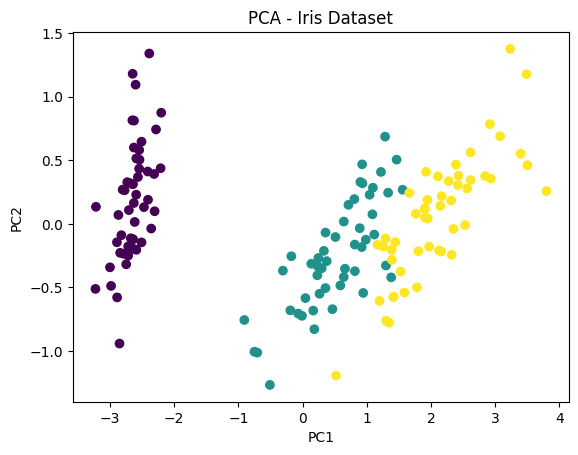

In [11]:
#🧪 Python Example

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Iris Dataset")
plt.show()

# **4. What is Naive Bayes?**
---

**Naive Bayes** is a **probabilistic classification algorithm** based on **Bayes' Theorem**, assuming that features are **conditionally independent** given the class label.

---

## 📌 Bayes’ Theorem Recap:

$$
P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}
$$

In classification terms:

$$
P(\text{Class}|\text{Data}) = \frac{P(\text{Data}|\text{Class}) \cdot P(\text{Class})}{P(\text{Data})}
$$

You **predict the class** with the **highest posterior probability**.

---

## 🧠 Naive Assumption

The algorithm assumes:

$$
P(x_1, x_2, ..., x_n | y) = P(x_1|y) \cdot P(x_2|y) \cdot \ldots \cdot P(x_n|y)
$$

This simplifies computation dramatically, especially with many features.

---

## 📦 Components of Naive Bayes

### 1. **Prior Probability** $P(y)$

* The probability of each class in the training data.

### 2. **Likelihood** $P(x_i | y)$

* The probability of feature $x_i$ given class $y$.

### 3. **Evidence** $P(x)$

* Often ignored in classification because it’s the same across all classes.

### 4. **Posterior Probability** $P(y|x)$

* The result of the Naive Bayes formula. Used to choose the predicted class.

---

## 🧪 Example: Spam Detection

Assume a training dataset with:

| Email   | Spam (y=1) | Word: "offer" | Word: "free" |
| ------- | ---------- | ------------- | ------------ |
| Email 1 | Yes        | Yes           | No           |
| Email 2 | No         | No            | No           |
| Email 3 | Yes        | Yes           | Yes          |
| Email 4 | No         | No            | Yes          |

Let’s classify a new email:
👉 contains "offer" but not "free".

### Step-by-Step:

#### Step 1: Calculate Priors

$$
P(\text{Spam}=1) = \frac{2}{4}, \quad P(\text{Spam}=0) = \frac{2}{4}
$$

#### Step 2: Calculate Likelihoods

$$
P(\text{offer}=1|\text{Spam}=1) = \frac{2}{2} = 1.0 \\
P(\text{free}=0|\text{Spam}=1) = \frac{1}{2}
$$

#### Step 3: Multiply Probabilities

$$
P(\text{Spam}=1|\text{email}) \propto P(\text{offer}=1|\text{Spam}=1) \cdot P(\text{free}=0|\text{Spam}=1) \cdot P(\text{Spam}=1)
$$

$$
= 1.0 \cdot 0.5 \cdot 0.5 = 0.25
$$

Do the same for Spam=0 and compare. Choose class with higher posterior.

---

## 🧠 Types of Naive Bayes

| Type            | Description                                                      | Use Case                         |
| --------------- | ---------------------------------------------------------------- | -------------------------------- |
| **Gaussian**    | Assumes features are continuous and follow a normal distribution | Sensor data, numerical features  |
| **Multinomial** | Works with count data (e.g., word counts)                        | Text classification              |
| **Bernoulli**   | Binary features (0/1)                                            | Spam detection, feature presence |

---

## ✨ Key Takeaways

* Naive Bayes uses **conditional probabilities** and **Bayes’ Theorem**.
* Despite the strong independence assumption, it works surprisingly well.
* Fast, interpretable, and great for baseline models.

---
---
---

In [12]:

## 🧮 Python Example

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

docs = ["free offer now", "hello friend", "limited free deal", "how are you"]
labels = [1, 0, 1, 0]  # 1=Spam, 0=Not Spam

vec = CountVectorizer()
X = vec.fit_transform(docs)

model = MultinomialNB()
model.fit(X, labels)

test = vec.transform(["free offer"])
print(model.predict(test))  # Output: [1] (spam)



[1]


# **5. What Are Activation Functions?**
---

In neural networks, **activation functions** decide **whether a neuron should be activated or not** by introducing non-linearity to the model.

Without them, your neural network would behave like a linear regression model — no matter how many layers you add.

---

## 🌟 Why Are Derivatives Important?

During **backpropagation**, we compute gradients (i.e., derivatives) to update weights via **gradient descent**. So, every activation function must be differentiable.

---

## 🔢 Most Common Activation Functions

| Function   | Equation                                               | Range   | Differentiability | Use                       |
| ---------- | ------------------------------------------------------ | ------- | ----------------- | ------------------------- |
| Sigmoid    | $\sigma(x) = \frac{1}{1 + e^{-x}}$                     | (0, 1)  | Yes               | Binary classification     |
| Tanh       | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$         | (–1, 1) | Yes               | Centered outputs          |
| ReLU       | $f(x) = \max(0, x)$                                    | \[0, ∞) | Yes (except at 0) | Most deep nets            |
| Leaky ReLU | $f(x) = \max(\alpha x, x)$                             | (–∞, ∞) | Yes               | Fixes ReLU dead neurons   |
| Softmax    | $\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$ | (0, 1)  | Yes               | Multiclass classification |

---

## 🧮 1. Sigmoid Function

### Equation:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

### Derivative:

$$
\sigma'(x) = \sigma(x)(1 - \sigma(x))
$$

### Pros:

* Good for binary output
* Smooth gradient

### Cons:

* Vanishing gradient problem
* Output not zero-centered

---

## 🧮 2. Tanh Function

### Equation:

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

### Derivative:

$$
\tanh'(x) = 1 - \tanh^2(x)
$$

### Pros:

* Zero-centered output
* Strong gradients for small values

### Cons:

* Still suffers from vanishing gradients

---

## ⚡ 3. ReLU (Rectified Linear Unit)

### Equation:

$$
f(x) = \max(0, x)
$$

### Derivative:

$$
f'(x) =
\begin{cases}
1 & \text{if } x > 0 \\
0 & \text{if } x \leq 0
\end{cases}
$$

### Pros:

* Fast computation
* Solves vanishing gradient

### Cons:

* "Dying ReLU" problem

---

## 🧊 4. Leaky ReLU

### Equation:

$$
f(x) = \begin{cases}
x & \text{if } x > 0 \\
\alpha x & \text{if } x \leq 0
\end{cases}
$$

Where $\alpha$ is a small constant like 0.01.

### Derivative:

$$
f'(x) = \begin{cases}
1 & \text{if } x > 0 \\
\alpha & \text{if } x \leq 0
\end{cases}
$$

---

## 🧠 5. Softmax (for Multiclass Outputs)

### Equation:

$$
\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^n e^{z_j}}
$$

### Derivative:

The softmax derivative is a bit more complex. For classes $i$ and $j$:

$$
\frac{\partial \text{Softmax}(z_i)}{\partial z_j} = \text{Softmax}(z_i)(\delta_{ij} - \text{Softmax}(z_j))
$$

Used with cross-entropy loss to simplify gradient computation.

---

## ✅ Summary Table

| Activation | Range              | Use Case                  | Vanishing Gradients? |
| ---------- | ------------------ | ------------------------- | -------------------- |
| Sigmoid    | 0 to 1             | Binary classification     | Yes                  |
| Tanh       | –1 to 1            | RNNs, NLP                 | Yes                  |
| ReLU       | 0 to ∞             | Deep CNNs, general        | No                   |
| Leaky ReLU | –∞ to ∞            | Improves ReLU             | No                   |
| Softmax    | 0 to 1 (per class) | Multiclass classification | No                   |

---
---
---

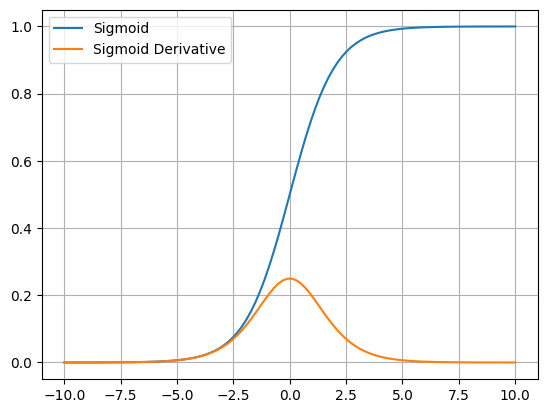

In [13]:
## 🧪 Practice in Python

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

x = np.linspace(-10, 10, 100)
plt.plot(x, sigmoid(x), label='Sigmoid')
plt.plot(x, sigmoid_derivative(x), label='Sigmoid Derivative')
plt.legend()
plt.grid()
plt.show()